# Model traing
in this notebook i am going to show how i train my model from data after eda is done

## importing library and data
### required library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings

import data as data drame

In [3]:
df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


preparing X and Y variables

In [5]:
X = df.drop(columns=['math_score'])

In [6]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
categorical_cols = [
    'gender',
    'race_ethnicity',
    'parental_level_of_education',
    'lunch',
    'test_preparation_course'
]

for col in categorical_cols:
    print(f"categories in '{col}':")
    print(df[col].unique())
    print()

categories in 'gender':
<StringArray>
['female', 'male']
Length: 2, dtype: str

categories in 'race_ethnicity':
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

categories in 'parental_level_of_education':
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

categories in 'lunch':
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

categories in 'test_preparation_course':
<StringArray>
['none', 'completed']
Length: 2, dtype: str



In [8]:
Y = df['math_score']
Y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [9]:
num_features = X.select_dtypes(exclude=['object']).columns
cat_features = X.select_dtypes(include=['object']).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(transformers=
    [
        ("onehot_encoder", categorical_transformer, cat_features),
        ("standard_scaler", numerical_transformer, num_features)
    ]
)
preprocessor

C:\Users\acer\AppData\Local\Temp\ipykernel_51612\568276628.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object']).columns


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot_encoder', ...), ('standard_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name

In [10]:
X = preprocessor.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [12]:
def evaluate_model(true, Predicted):
    mae = mean_absolute_error(true, Predicted)
    mse = mean_squared_error(true, Predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, Predicted)
    return mae, mse, rmse, r2

In [16]:
models={
    "linear_regression": LinearRegression(),
    "ridge": Ridge(),
    "lasso": Lasso(),
    "decision_tree": DecisionTreeRegressor(),
    "random_forest": RandomForestClassifier(),
    "knn": KNeighborsRegressor(),
    "xgb": XGBRegressor(),
    "catboost": CatBoostRegressor(verbose=False),
    "adaboost": AdaBoostClassifier()
}

models_list = []
r2_scores = [] 

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train, y_train)
    
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    model_test_mea, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    model_train_mea, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    
    print(f"Model: {list(models.keys())[i]}")
    models_list.append(list(models.keys())[i])
    
    print(f"model performance on train set: \nMAE: {model_train_mea:.4f}\nRMSE: {model_train_rmse:.4f}\nR2: {model_train_r2:.4f}")
    print(f"model performance on test set: \nMAE: {model_test_mea:.4f}\nRMSE: {model_test_rmse:.4f}\nR2: {model_test_r2:.4f}")
    
    r2_scores.append(model_test_r2)
    print("="*35)
    print()

Model: linear_regression
model performance on train set: 
MAE: 4.2667
RMSE: 5.3231
R2: 0.8743
model performance on test set: 
MAE: 4.2148
RMSE: 5.3940
R2: 0.8804

Model: ridge
model performance on train set: 
MAE: 4.2650
RMSE: 5.3233
R2: 0.8743
model performance on test set: 
MAE: 4.2111
RMSE: 5.3904
R2: 0.8806

Model: lasso
model performance on train set: 
MAE: 5.2063
RMSE: 6.5938
R2: 0.8071
model performance on test set: 
MAE: 5.1579
RMSE: 6.5197
R2: 0.8253

Model: decision_tree
model performance on train set: 
MAE: 0.0187
RMSE: 0.2795
R2: 0.9997
model performance on test set: 
MAE: 6.4200
RMSE: 8.1166
R2: 0.7293

Model: random_forest
model performance on train set: 
MAE: 0.0187
RMSE: 0.3953
R2: 0.9993
model performance on test set: 
MAE: 7.2650
RMSE: 9.3271
R2: 0.6425

Model: knn
model performance on train set: 
MAE: 4.5167
RMSE: 5.7077
R2: 0.8555
model performance on test set: 
MAE: 5.6210
RMSE: 7.2530
R2: 0.7838

Model: xgb
model performance on train set: 
MAE: 0.6875
RMSE: 1.0073

In [17]:
pd.DataFrame(list(zip(models_list, r2_scores)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
1,ridge,0.880593
0,linear_regression,0.880433
7,catboost,0.851632
6,xgb,0.827797
2,lasso,0.825320
5,knn,0.783813
3,decision_tree,0.729266
4,random_forest,0.642494
8,adaboost,0.246625


In [19]:
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(X_train, y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test, y_pred)*100
print(f"R2 score of Linear Regression model is: {score:.2f}%")

R2 score of Linear Regression model is: 88.04%


Text(0, 0.5, 'Predicted Values')

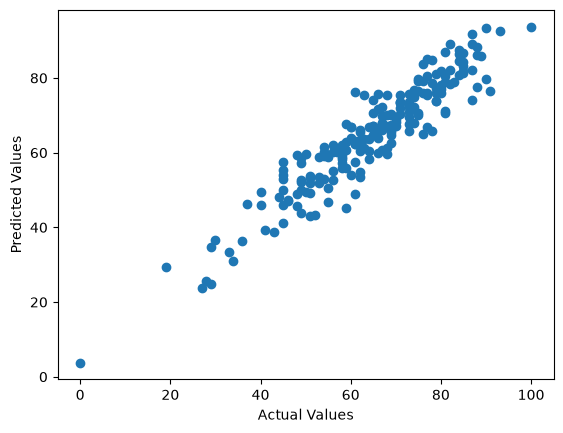

In [20]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

<Axes: xlabel='math_score'>

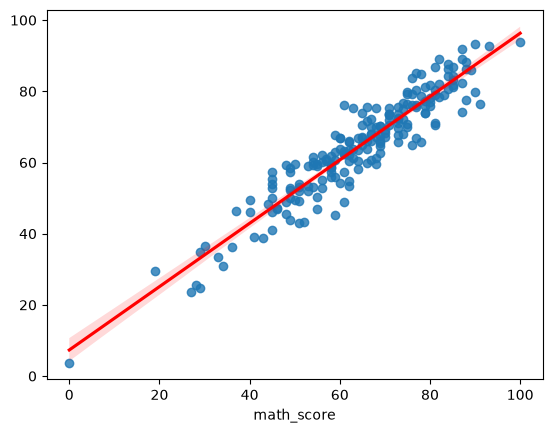

In [21]:
sns.regplot(x=y_test, y=y_pred, line_kws={"color":"red"})

In [22]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
